# 📘 **Notebook 13 — Capstone: End-to-End Fraud Detection using Graph + ML**

---

## 🧠 Objective

> Build a full fraud detection pipeline using:

* Graph construction
* Graph features
* Embeddings
* Machine learning

---

## 🔄 Pipeline Overview

```python
# Flow:
# Data → Graph → Features → Embeddings → ML Model → Evaluation
```

---

# 📦 1. Setup


In [1]:


# Install required libraries (run once)
# !pip install networkx numpy pandas scikit-learn node2vec matplotlib

import numpy as np
import pandas as pd
import networkx as nx
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

import matplotlib.pyplot as plt




---

# 🧪 2. Generate Synthetic Fraud Data

---


In [2]:
def generate_data(num_nodes=200):
    edges = []
    fraud_nodes = set(random.sample(range(num_nodes), k=20))
    
    for i in range(num_nodes):
        for _ in range(random.randint(1, 4)):
            j = random.randint(0, num_nodes-1)
            if i != j:
                edges.append((i, j))
    
    # Add fraud ring (dense cluster)
    fraud_list = list(fraud_nodes)
    for i in fraud_list:
        for j in fraud_list:
            if i != j:
                edges.append((i, j))
    
    df = pd.DataFrame(edges, columns=["src", "dst"])
    df["label"] = df["src"].apply(lambda x: 1 if x in fraud_nodes else 0)
    
    return df, fraud_nodes

df, fraud_nodes = generate_data()
df.head()


,src,dst,label
0,0,148,0
1,1,156,0
2,2,167,0
3,2,16,0
4,2,90,0




---

# 🔗 3. Build Graph

---


In [3]:

G = nx.from_pandas_edgelist(df, "src", "dst", create_using=nx.Graph())

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())



Nodes: 200
Edges: 688


---

# 📊 4. Visualize Graph (Optional)

---


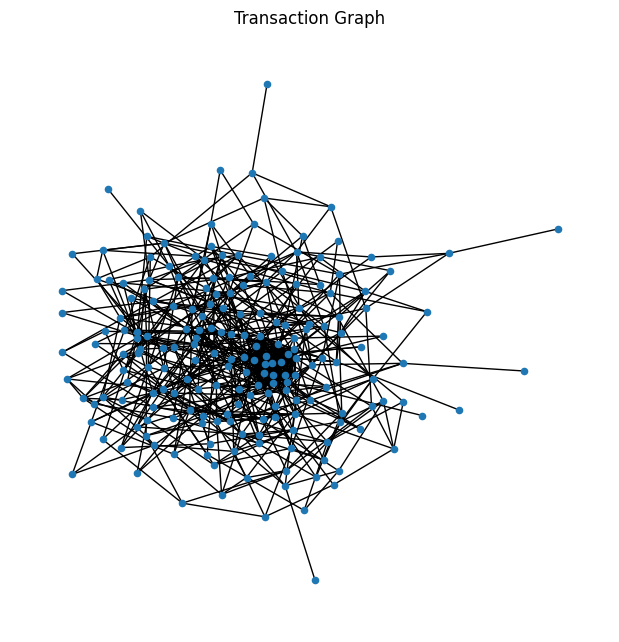

In [4]:


plt.figure(figsize=(6,6))
nx.draw(G, node_size=20)
plt.title("Transaction Graph")
plt.show()



---

# ⚙️ 5. Graph Feature Engineering

---


In [5]:
degree_dict = dict(G.degree())
pagerank_dict = nx.pagerank(G)
betweenness_dict = nx.betweenness_centrality(G)

features = []

for node in G.nodes():
    features.append({
        "node": node,
        "degree": degree_dict[node],
        "pagerank": pagerank_dict[node],
        "betweenness": betweenness_dict[node],
        "label": 1 if node in fraud_nodes else 0
    })

features_df = pd.DataFrame(features)
features_df.head()


,node,degree,pagerank,betweenness,label
0,0,3,0.002919,0.001976,0
1,148,5,0.004473,0.006340,0
2,1,4,0.003558,0.003831,0
3,156,9,0.006569,0.024548,0
4,2,5,0.003375,0.005530,0



---

# 🧠 6. Graph Embeddings (Node2Vec)

---

In [6]:
from node2vec import Node2Vec

node2vec = Node2Vec(G, dimensions=16, walk_length=10, num_walks=50, workers=2)
model = node2vec.fit(window=5, min_count=1)


embeddings = []

for node in G.nodes():
    emb = model.wv[str(node)]
    embeddings.append([node] + list(emb))

emb_df = pd.DataFrame(embeddings)
emb_df.columns = ["node"] + [f"emb_{i}" for i in range(16)]

emb_df.head()



/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating walks (CPU: 2): 100%|██████████| 25/25 [00:00<00:00, 64.71it/s]


,node,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15
0,0,0.267317,-1.008631,1.036502,0.384251,0.101281,1.128727,1.539110,0.121500,0.748028,-0.191702,0.560667,-0.536136,-0.659195,0.368478,0.169294,0.067471
1,148,-0.163852,-0.975004,0.890951,0.654382,0.567926,1.189789,1.581013,0.062726,0.821047,0.400945,1.007224,-0.284493,-0.014612,0.561380,-0.172178,-0.134426
2,1,0.862419,0.116726,0.785014,0.849106,0.029720,-0.174843,1.236077,0.487573,-0.438029,0.428922,1.105324,-0.347156,0.006157,0.112420,0.157287,1.454947
3,156,0.896825,-0.172109,0.751153,0.158080,0.275207,0.267297,0.772036,0.580239,-0.446234,0.397763,0.544127,-0.560782,0.504842,0.253377,-0.076453,0.930592
4,2,0.815187,-0.680052,-0.029093,0.480742,0.259989,-0.591058,1.271570,0.261851,-0.087904,0.274988,-0.567926,0.348294,0.088776,-0.570292,-0.780989,-0.417170


---

# 🔗 7. Merge Features + Embeddings

---


In [7]:
final_df = features_df.merge(emb_df, on="node")
final_df.head()

,node,degree,pagerank,betweenness,label,emb_0,emb_1,emb_2,emb_3,emb_4,...,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15
0,0,3,0.002919,0.001976,0,0.267317,-1.008631,1.036502,0.384251,0.101281,...,1.539110,0.121500,0.748028,-0.191702,0.560667,-0.536136,-0.659195,0.368478,0.169294,0.067471
1,148,5,0.004473,0.006340,0,-0.163852,-0.975004,0.890951,0.654382,0.567926,...,1.581013,0.062726,0.821047,0.400945,1.007224,-0.284493,-0.014612,0.561380,-0.172178,-0.134426
2,1,4,0.003558,0.003831,0,0.862419,0.116726,0.785014,0.849106,0.029720,...,1.236077,0.487573,-0.438029,0.428922,1.105324,-0.347156,0.006157,0.112420,0.157287,1.454947
3,156,9,0.006569,0.024548,0,0.896825,-0.172109,0.751153,0.158080,0.275207,...,0.772036,0.580239,-0.446234,0.397763,0.544127,-0.560782,0.504842,0.253377,-0.076453,0.930592
4,2,5,0.003375,0.005530,0,0.815187,-0.680052,-0.029093,0.480742,0.259989,...,1.271570,0.261851,-0.087904,0.274988,-0.567926,0.348294,0.088776,-0.570292,-0.780989,-0.417170


# 🤖 8. Model Training

---


In [8]:


X = final_df.drop(columns=["node", "label"])
y = final_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

---

# 📊 9. Evaluation

---


In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00         4

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

ROC-AUC: 1.0


---

# 🔍 10. Feature Importance

---


In [10]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)


degree         0.314409
pagerank       0.297744
emb_14         0.091318
betweenness    0.078098
emb_7          0.052924
emb_8          0.046529
emb_10         0.025622
emb_5          0.017227
emb_1          0.014235
emb_6          0.012320
dtype: float64

---

# 🧠 Key Observations

---
markdown
- Graph features like degree & pagerank help identify active nodes
- Betweenness captures intermediary fraud behavior
- Node2Vec embeddings capture hidden structure
- Combining both significantly improves performance



---

# 🔥 11. Simulating Real Fraud Detection

---

In [11]:
def predict_node(node_id):
    row = final_df[final_df["node"] == node_id].drop(columns=["node", "label"])
    prob = model.predict_proba(row)[0][1]
    return prob

# Example
predict_node(10)


0.0

---

# 🚀 12. Key Takeaways

---
✅ Graph-based features improve fraud detection  
✅ Embeddings capture hidden relationships  
✅ Combining graph + ML gives strong results  
✅ This pipeline mimics real-world fraud systems  



---
# ⚠️ Limitations
---

- Synthetic data (not real-world complexity)
- No temporal features
- No real-time system

---

## 💡 Add These:

* Community detection (Louvain)
* Link prediction features
* GraphSAGE embeddings
* Temporal features
* Stream processing simulation

---

